# Лабораторная работа №4

**Тема:** оптимизация архитектуры полносвязной нейронной сети с помощью эволюционного алгоритма.

Цель работы — разработать эволюционную программу, которая автоматически подбирает структуру полносвязной нейронной сети для классификации данных с большим числом признаков. Фитнес учитывает точность классификации и штраф за сложность модели.


## Датасет и смысл имитации Big Data

В задании сказано выбрать реальный или синтетический датасет с `50-100` входными признаками. Для более строгого выполнения выбран реальный датасет **Forest Covertype** из `sklearn.datasets.fetch_covtype`.

Характеристики датасета:

- `581012` объектов;
- `54` входных признака;
- `7` классов лесного покрова;
- задача многоклассовой классификации.

Здесь “имитация Big Data” означает не промышленный кластер Hadoop/Spark, а учебную имитацию работы с большим набором: много строк, 50+ признаков, загрузка реального крупного датасета, чанковая нормализация, стратифицированная подвыборка для дорогого этапа эволюционного поиска и финальная проверка на большом тестовом наборе. Финальная модель проверяется на большом тестовом наборе.


In [28]:
from dataclasses import dataclass
from pathlib import Path
from time import perf_counter
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_covtype
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

notebook_root = Path.cwd()
lab_dir = notebook_root / "EVAL" / "lab_4" if (notebook_root / "EVAL" / "lab_4").exists() else notebook_root
data_dir = lab_dir / "data"
output_dir = lab_dir / "results"
data_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

print("Используемое устройство:", DEVICE)

CONFIG = {
    "population_size": 14,
    "generations": 25,
    "elite_count": 3,
    "tournament_size": 3,
    "mutation_rate": 0.85,
    "base_immigrants": 1,
    "stagnation_limit": 4,
    "stagnation_immigrants": 5,
    "min_layers": 1,
    "max_layers": 5,
    "neuron_options": [32, 48, 64, 96, 128, 160, 224, 256],
    "activations": ["relu", "tanh", "elu"],
    "l2_options": [0.0, 1e-5, 1e-4, 5e-4, 1e-3],
    "eval_epochs": 5,
    "final_epochs": 15,
    "early_stop_patience": 2,
    "eval_learning_rate": 0.003,
    "final_learning_rate": 0.0025,
    "batch_size": 1024,
    "predict_batch_size": 4096,
    "search_train_size": 50_000,
    "search_val_size": 12_000,
    "layer_penalty": 0.0015,
    "param_penalty": 0.003,
}



Используемое устройство: cuda


## Загрузка реального датасета

Датасет `Covertype` скачивается один раз в папку `EVAL/lab_4/data`. При повторном запуске он берется из локального кэша.


In [ ]:
start_load = perf_counter()
covtype = fetch_covtype(data_home=str(data_dir), download_if_missing=True, as_frame=False)
X = covtype.data.astype(np.float32)
y = (covtype.target.astype(np.int64) - 1)
load_time = perf_counter() - start_load

N_SAMPLES, N_FEATURES = X.shape
N_CLASSES = int(np.max(y) + 1)

print("Размер датасета:", X.shape)
print("Количество классов:", N_CLASSES)
print("Время загрузки, с:", round(load_time, 2))
print("Распределение классов:", np.bincount(y))


Размер датасета: (581012, 54)
Количество классов: 7
Время загрузки, с: 0.45
Распределение классов: [211840 283301  35754   2747   9493  17367  20510]


## Разбиение и чанковая нормализация

Чтобы показать обработку большого набора данных, среднее и стандартное отклонение считаются по частям. Это похоже на ситуацию, когда датасет нельзя или неудобно обрабатывать одной операцией.


In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=RANDOM_SEED, stratify=y_train_full
)


def fit_scaler_by_chunks(data: np.ndarray, chunk_size: int = 25000) -> tuple[np.ndarray, np.ndarray]:
    "Считает среднее и стандартное отклонение признаков по частям."
    total_count = 0
    total_sum = np.zeros(data.shape[1], dtype=np.float64)
    total_square_sum = np.zeros(data.shape[1], dtype=np.float64)

    for start in range(0, len(data), chunk_size):
        chunk = data[start:start + chunk_size].astype(np.float64)
        total_count += len(chunk)
        total_sum += chunk.sum(axis=0)
        total_square_sum += (chunk ** 2).sum(axis=0)

    mean = total_sum / total_count
    variance = total_square_sum / total_count - mean ** 2
    std = np.sqrt(np.maximum(variance, 1e-8))
    return mean.astype(np.float32), std.astype(np.float32)


def transform_by_chunks(data: np.ndarray, mean: np.ndarray, std: np.ndarray, chunk_size: int = 25000) -> np.ndarray:
    "Применяет нормализацию к данным по частям, используя заданные среднее и стандартное отклонение."
    result = np.empty_like(data, dtype=np.float32)
    for start in range(0, len(data), chunk_size):
        result[start:start + chunk_size] = (data[start:start + chunk_size] - mean) / std
    return result


mean, std = fit_scaler_by_chunks(X_train)
X_train = transform_by_chunks(X_train, mean, std)
X_val = transform_by_chunks(X_val, mean, std)
X_test = transform_by_chunks(X_test, mean, std)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (371847, 54)
Validation: (92962, 54)
Test: (116203, 54)


In [ ]:
def stratified_sample_indices(y_data: np.ndarray, sample_size: int, seed: int) -> np.ndarray:
    "Делает подвыборку с сохранением пропорций классов."
    rng = np.random.default_rng(seed)
    selected = []
    for class_id in np.unique(y_data):
        class_indices = np.flatnonzero(y_data == class_id)
        take = max(1, int(round(sample_size * len(class_indices) / len(y_data))))
        take = min(take, len(class_indices))
        selected.append(rng.choice(class_indices, size=take, replace=False))
    result = np.concatenate(selected)
    rng.shuffle(result)
    return result[:sample_size]


# Обучать 12 сетей * 20 поколений на всех 371k train-объектах слишком долго.
# Поэтому эволюционный поиск идет на репрезентативной стратифицированной подвыборке,
# а финальная модель затем учится и проверяется на больших наборах.
search_train_indices = stratified_sample_indices(y_train, sample_size=CONFIG["search_train_size"], seed=RANDOM_SEED)
search_val_indices = stratified_sample_indices(y_val, sample_size=CONFIG["search_val_size"], seed=RANDOM_SEED + 1)

X_search_train = X_train[search_train_indices]
y_search_train = y_train[search_train_indices]
X_search_val = X_val[search_val_indices]
y_search_val = y_val[search_val_indices]

print("Подвыборка для эволюции:", X_search_train.shape, X_search_val.shape)
print("Распределение классов в поисковой train-подвыборке:", np.bincount(y_search_train, minlength=N_CLASSES))


Подвыборка для эволюции: (50000, 54) (12000, 54)
Распределение классов в поисковой train-подвыборке: [18229 24380  3077   237   817  1495  1765]


## Генотип особи

Особь — это описание архитектуры нейронной сети:

1. количество скрытых слоев;
2. количество нейронов в каждом скрытом слое;
3. функция активации;
4. коэффициент L2-регуляризации.

Фитнес максимизируется. Он основан на `Accuracy`, но уменьшается за большое число параметров и лишние слои.


In [ ]:
@dataclass
class Individual:
    "Описание индивида популяции"
    hidden_layers: list[int]
    activation: str
    l2: float
    fitness: float | None = None
    accuracy: float | None = None
    f1: float | None = None
    param_count: int | None = None


ACTIVATIONS = CONFIG["activations"]
NEURON_OPTIONS = CONFIG["neuron_options"]
L2_OPTIONS = CONFIG["l2_options"]
MIN_LAYERS = CONFIG["min_layers"]
MAX_LAYERS = CONFIG["max_layers"]


def clone_individual(individual: Individual) -> Individual:
    "Создает копию особи"
    return Individual(
        hidden_layers=list(individual.hidden_layers),
        activation=individual.activation,
        l2=individual.l2,
        fitness=individual.fitness,
        accuracy=individual.accuracy,
        f1=individual.f1,
        param_count=individual.param_count,
    )


def random_individual() -> Individual:
    "Создает случайную архитектуру нейросети в рамках заданных ограничений"
    layer_count = random.randint(MIN_LAYERS, MAX_LAYERS)
    hidden_layers = [random.choice(NEURON_OPTIONS) for _ in range(layer_count)]
    return Individual(hidden_layers=hidden_layers, activation=random.choice(ACTIVATIONS), l2=random.choice(L2_OPTIONS))


def activation_layer(name: str) -> nn.Module:
    "По строке возвращает слой активации PyTorch"
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "elu":
        return nn.ELU()
    raise ValueError(name)


def build_model(individual: Individual) -> nn.Sequential:
    "Строит реальную нейросеть из особи с заданными параметрами архитектуры"
    layers = []
    previous_dim = N_FEATURES
    for hidden_dim in individual.hidden_layers:
        layers.append(nn.Linear(previous_dim, hidden_dim))
        layers.append(activation_layer(individual.activation))
        previous_dim = hidden_dim
    layers.append(nn.Linear(previous_dim, N_CLASSES))
    return nn.Sequential(*layers)


def count_parameters(model: nn.Module) -> int:
    "Считает обучаемые параметры сети"
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def describe_individual(individual: Individual) -> str:
    "Делает красивое текстовое описание архитектуры особи"
    layers = "-".join(str(item) for item in individual.hidden_layers)
    return f"слои=[{layers}], activation={individual.activation}, l2={individual.l2}"

def architecture_key(individual: Individual) -> tuple[tuple[int, ...], str, float]:
    "Создает “ключ” архитектуры для сравнения и хранения результатов в словаре"
    return tuple(individual.hidden_layers), individual.activation, individual.l2



## Обучение временной модели и расчет фитнеса

Каждая особь превращается во временную нейросеть. Сеть обучается небольшое число эпох, затем оценивается на валидационной подвыборке. Это основной затратный этап эволюции.


In [ ]:
def make_loader(X_data: np.ndarray, y_data: np.ndarray, batch_size: int = CONFIG["batch_size"], shuffle: bool = True) -> DataLoader:
    "Создает DataLoader для PyTorch"
    dataset = TensorDataset(torch.tensor(X_data, dtype=torch.float32), torch.tensor(y_data, dtype=torch.long))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def predict_labels(model: nn.Module, X_data: np.ndarray, batch_size: int = CONFIG["predict_batch_size"]) -> np.ndarray:
    "Прогоняет данные через модель и возвращает предсказанные классы"
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, len(X_data), batch_size):
            batch = torch.tensor(X_data[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            logits = model(batch)
            predictions.append(torch.argmax(logits, dim=1).cpu().numpy())
    return np.concatenate(predictions)


def make_class_weights(y_data: np.ndarray) -> torch.Tensor:
    "Считает веса классов для CrossEntropyLoss на основе распределения в данных"
    counts = np.bincount(y_data, minlength=N_CLASSES).astype(np.float32)
    weights = np.sqrt(counts.sum() / np.maximum(counts, 1.0))
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def train_model(
    individual: Individual,
    X_train_data: np.ndarray,
    y_train_data: np.ndarray,
    X_val_data: np.ndarray,
    y_val_data: np.ndarray,
    epochs: int = CONFIG["eval_epochs"],
    learning_rate: float = CONFIG["eval_learning_rate"],
    patience: int = CONFIG["early_stop_patience"],
) -> tuple[nn.Module, dict[str, float]]:
    "Обучает модель, описанную особью, и возвращает обученную модель и метрики на валидации"
    torch.manual_seed(RANDOM_SEED)
    model = build_model(individual).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=individual.l2)
    criterion = nn.CrossEntropyLoss(weight=make_class_weights(y_train_data))
    loader = make_loader(X_train_data, y_train_data, batch_size=CONFIG["batch_size"], shuffle=True)

    best_state = copy.deepcopy(model.state_dict())
    best_accuracy = 0.0
    wait = 0

    for _ in range(epochs):
        model.train()
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()

        val_predictions = predict_labels(model, X_val_data)
        val_accuracy = accuracy_score(y_val_data, val_predictions)
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    predictions = predict_labels(model, X_val_data)
    accuracy = accuracy_score(y_val_data, predictions)
    f1 = f1_score(y_val_data, predictions, average="macro")
    params = count_parameters(model)
    return model, {"accuracy": accuracy, "f1": f1, "params": params}


def evaluate_individual(individual: Individual) -> Individual:
    "Фитнес-функция"
    _, metrics = train_model(
        individual,
        X_search_train,
        y_search_train,
        X_search_val,
        y_search_val,
        epochs=CONFIG["eval_epochs"],
        learning_rate=CONFIG["eval_learning_rate"],
        patience=CONFIG["early_stop_patience"],
    )
    complexity_penalty = CONFIG["param_penalty"] * np.log10(metrics["params"])
    layer_penalty = CONFIG["layer_penalty"] * max(0, len(individual.hidden_layers) - CONFIG["min_layers"])
    individual.accuracy = float(metrics["accuracy"])
    individual.f1 = float(metrics["f1"])
    individual.param_count = int(metrics["params"])
    individual.fitness = float(individual.accuracy - complexity_penalty - layer_penalty)
    return individual


## Эволюционный алгоритм

Параметры вынесены в словарь `CONFIG`. По рекомендации из задания используется небольшая популяция и `25` поколений. Диапазон числа скрытых слоев расширен до `1..5`, а рост модели контролируется не жестким запретом, а штрафом в фитнес-функции. Используются элитизм, турнирный отбор, скрещивание, мутация и ранняя остановка при обучении временных моделей.


In [ ]:
POPULATION_SIZE = CONFIG["population_size"]
GENERATIONS = CONFIG["generations"]
ELITE_COUNT = CONFIG["elite_count"]
TOURNAMENT_SIZE = CONFIG["tournament_size"]
MUTATION_RATE = CONFIG["mutation_rate"]
BASE_IMMIGRANTS = CONFIG["base_immigrants"]
STAGNATION_LIMIT = CONFIG["stagnation_limit"]
STAGNATION_IMMIGRANTS = CONFIG["stagnation_immigrants"]


def architecture_key(individual: Individual) -> tuple[tuple[int, ...], str, float]:
    return tuple(individual.hidden_layers), individual.activation, individual.l2


def tournament_selection(population: list[Individual]) -> Individual:
    "Турнирный отбор родителей"
    candidates = random.sample(population, TOURNAMENT_SIZE)
    return clone_individual(max(candidates, key=lambda item: item.fitness))


def crossover(parent_a: Individual, parent_b: Individual) -> Individual:
    "Скрещивает две архитектуры"
    cut_a = random.randint(1, len(parent_a.hidden_layers))
    cut_b = random.randint(0, len(parent_b.hidden_layers) - 1)
    child_layers = parent_a.hidden_layers[:cut_a] + parent_b.hidden_layers[cut_b:]
    child_layers = child_layers[:MAX_LAYERS]
    if len(child_layers) < MIN_LAYERS:
        child_layers = [random.choice(NEURON_OPTIONS) for _ in range(MIN_LAYERS)]
    return Individual(
        hidden_layers=child_layers,
        activation=random.choice([parent_a.activation, parent_b.activation]),
        l2=random.choice([parent_a.l2, parent_b.l2]),
    )


def mutate(individual: Individual) -> Individual:
    "Случайно изменяет архитектуру"
    result = clone_individual(individual)
    mutation_type = random.choice(["neurons", "add_layer", "remove_layer", "activation", "l2", "replace_all"])

    if mutation_type == "neurons":
        index = random.randrange(len(result.hidden_layers))
        current = result.hidden_layers[index]
        step = random.choice([-64, -32, 32, 64])
        result.hidden_layers[index] = min(NEURON_OPTIONS, key=lambda value: abs(value - (current + step)))
    elif mutation_type == "add_layer" and len(result.hidden_layers) < MAX_LAYERS:
        index = random.randint(0, len(result.hidden_layers))
        result.hidden_layers.insert(index, random.choice(NEURON_OPTIONS))
    elif mutation_type == "remove_layer" and len(result.hidden_layers) > MIN_LAYERS:
        index = random.randrange(len(result.hidden_layers))
        result.hidden_layers.pop(index)
    elif mutation_type == "activation":
        result.activation = random.choice(ACTIVATIONS)
    elif mutation_type == "l2":
        result.l2 = random.choice(L2_OPTIONS)
    elif mutation_type == "replace_all":
        result = random_individual()

    result.fitness = None
    result.accuracy = None
    result.f1 = None
    result.param_count = None
    return result


def make_unique_initial_population() -> list[Individual]:
    "Создает начальную популяцию без одинаковых архитектур"
    population = []
    used_keys = set()
    while len(population) < POPULATION_SIZE:
        candidate = random_individual()
        key = architecture_key(candidate)
        if key in used_keys:
            continue
        used_keys.add(key)
        population.append(evaluate_individual(candidate))
    return population


def add_candidate_if_unique(candidate: Individual, next_population: list[Individual], used_keys: set) -> bool:
    "Добавляет ребенка в новое поколение только если такой архитектуры еще нет"
    key = architecture_key(candidate)
    if key in used_keys:
        return False
    used_keys.add(key)
    next_population.append(evaluate_individual(candidate))
    return True


def run_evolution() -> tuple[list[Individual], list[dict[str, float]]]:
    population = make_unique_initial_population()
    history = []
    best_ever = None
    stagnant_generations = 0

    for generation in range(1, GENERATIONS + 1):
        population = sorted(population, key=lambda item: item.fitness, reverse=True)
        best = population[0]

        if best_ever is None or best.fitness > best_ever.fitness + 1e-4:
            best_ever = clone_individual(best)
            stagnant_generations = 0
        else:
            stagnant_generations += 1

        unique_count = len({architecture_key(item) for item in population})
        average_accuracy = float(np.mean([item.accuracy for item in population]))
        average_fitness = float(np.mean([item.fitness for item in population]))
        history.append({
            "generation": generation,
            "best_accuracy": best.accuracy,
            "average_accuracy": average_accuracy,
            "best_fitness": best.fitness,
            "average_fitness": average_fitness,
            "best_f1": best.f1,
            "best_params": best.param_count,
            "best_layers": len(best.hidden_layers),
            "unique_architectures": unique_count,
            "stagnant_generations": stagnant_generations,
        })

        if stagnant_generations == 0:
            leader_text = f"новый лидер: {describe_individual(best)}"
        else:
            leader_text = f"плато {stagnant_generations}; лидер прежний, проверены новые архитектуры"
        print(
            f"Поколение {generation:02d}: "
            f"best_acc={best.accuracy:.4f}, avg_acc={average_accuracy:.4f}, "
            f"fitness={best.fitness:.4f}, unique={unique_count}; "
            f"{leader_text}"
        )

        next_population = [clone_individual(item) for item in population[:ELITE_COUNT]]
        used_keys = {architecture_key(item) for item in next_population}

        immigrant_count = STAGNATION_IMMIGRANTS if stagnant_generations >= STAGNATION_LIMIT else BASE_IMMIGRANTS
        for _ in range(immigrant_count):
            attempts = 0
            while len(next_population) < POPULATION_SIZE and attempts < 30:
                attempts += 1
                if add_candidate_if_unique(random_individual(), next_population, used_keys):
                    break

        while len(next_population) < POPULATION_SIZE:
            attempts = 0
            added = False
            while attempts < 30 and not added:
                attempts += 1
                parent_a = tournament_selection(population)
                parent_b = tournament_selection(population)
                child = crossover(parent_a, parent_b)
                if random.random() < MUTATION_RATE:
                    child = mutate(child)
                added = add_candidate_if_unique(child, next_population, used_keys)
            if not added:
                add_candidate_if_unique(random_individual(), next_population, used_keys)

        population = next_population

    population = sorted(population, key=lambda item: item.fitness, reverse=True)
    return population, history


start_time = perf_counter()
final_population, history = run_evolution()
evolution_time = perf_counter() - start_time
best_individual = final_population[0]

print()
print("Лучшая найденная архитектура:", describe_individual(best_individual))
print("Accuracy на поисковой валидации:", round(best_individual.accuracy, 4))
print("F1 на поисковой валидации:", round(best_individual.f1, 4))
print("Параметров:", best_individual.param_count)
print("Время эволюции, с:", round(evolution_time, 2))


Поколение 01: best_acc=0.7413, avg_acc=0.7264, fitness=0.7237, unique=14; новый лидер: слои=[224-128-256], activation=tanh, l2=0.0005
Поколение 02: best_acc=0.7516, avg_acc=0.7315, fitness=0.7369, unique=14; новый лидер: слои=[128-128], activation=relu, l2=0.0
Поколение 03: best_acc=0.7516, avg_acc=0.7388, fitness=0.7369, unique=14; плато 1; лидер прежний, проверены новые архитектуры
Поколение 04: best_acc=0.7516, avg_acc=0.7376, fitness=0.7369, unique=14; плато 2; лидер прежний, проверены новые архитектуры
Поколение 05: best_acc=0.7516, avg_acc=0.7342, fitness=0.7369, unique=14; плато 3; лидер прежний, проверены новые архитектуры
Поколение 06: best_acc=0.7516, avg_acc=0.7395, fitness=0.7369, unique=14; плато 4; лидер прежний, проверены новые архитектуры
Поколение 07: best_acc=0.7516, avg_acc=0.7380, fitness=0.7369, unique=14; плато 5; лидер прежний, проверены новые архитектуры
Поколение 08: best_acc=0.7534, avg_acc=0.7361, fitness=0.7380, unique=14; новый лидер: слои=[224-128], activa

## Финальное обучение и сравнение с базовой моделью

Лучшая архитектура обучается на полном тренировочном наборе. Для сравнения используется вручную заданная базовая модель: один скрытый слой на 32 нейрона с ReLU. Финальное число эпох также берется из `CONFIG`.


In [35]:
def final_train_and_test(individual: Individual, epochs: int = CONFIG["final_epochs"]) -> dict[str, object]:
    model, val_metrics = train_model(
        individual,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=epochs,
        learning_rate=CONFIG["final_learning_rate"],
        patience=CONFIG["early_stop_patience"] + 1,
    )
    test_predictions = predict_labels(model, X_test)
    return {
        "model": model,
        "validation_accuracy": val_metrics["accuracy"],
        "validation_f1": val_metrics["f1"],
        "test_accuracy": accuracy_score(y_test, test_predictions),
        "test_f1": f1_score(y_test, test_predictions, average="macro"),
        "test_predictions": test_predictions,
        "params": count_parameters(model),
    }


baseline_individual = Individual(hidden_layers=[32], activation="relu", l2=1e-4)

final_start = perf_counter()
evolved_metrics = final_train_and_test(best_individual, epochs=CONFIG["final_epochs"])
baseline_metrics = final_train_and_test(baseline_individual, epochs=CONFIG["final_epochs"])
final_training_time = perf_counter() - final_start

comparison = pd.DataFrame([
    {
        "Модель": "Эволюционно найденная",
        "Архитектура": describe_individual(best_individual),
        "Accuracy test": evolved_metrics["test_accuracy"],
        "F1 test": evolved_metrics["test_f1"],
        "Параметров": evolved_metrics["params"],
    },
    {
        "Модель": "Базовая",
        "Архитектура": describe_individual(baseline_individual),
        "Accuracy test": baseline_metrics["test_accuracy"],
        "F1 test": baseline_metrics["test_f1"],
        "Параметров": baseline_metrics["params"],
    },
])
comparison


,Модель,Архитектура,Accuracy test,F1 test,Параметров
0,Эволюционно найденная,"слои=[256-128], activation=relu, l2=0.0001",0.873988,0.820313,47879
1,Базовая,"слои=[32], activation=relu, l2=0.0001",0.765350,0.667174,1991


## Визуализация результатов

Строятся обязательные графики: динамика лучшей и средней Accuracy, структура лучшей сети, матрица ошибок и сравнение с базовой моделью.


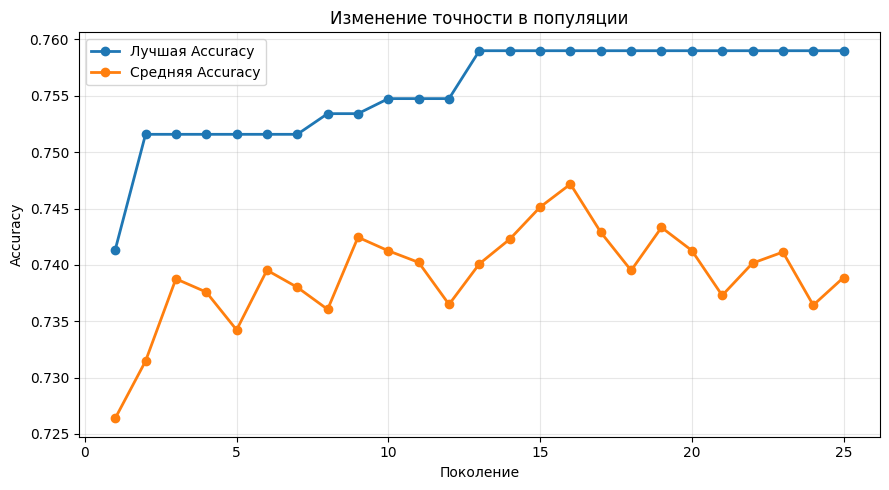

In [36]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(9, 5))
plt.plot(history_df["generation"], history_df["best_accuracy"], marker="o", linewidth=2, label="Лучшая Accuracy")
plt.plot(history_df["generation"], history_df["average_accuracy"], marker="o", linewidth=2, label="Средняя Accuracy")
plt.xlabel("Поколение")
plt.ylabel("Accuracy")
plt.title("Изменение точности в популяции")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "evolution_accuracy.png", dpi=160)
plt.show()


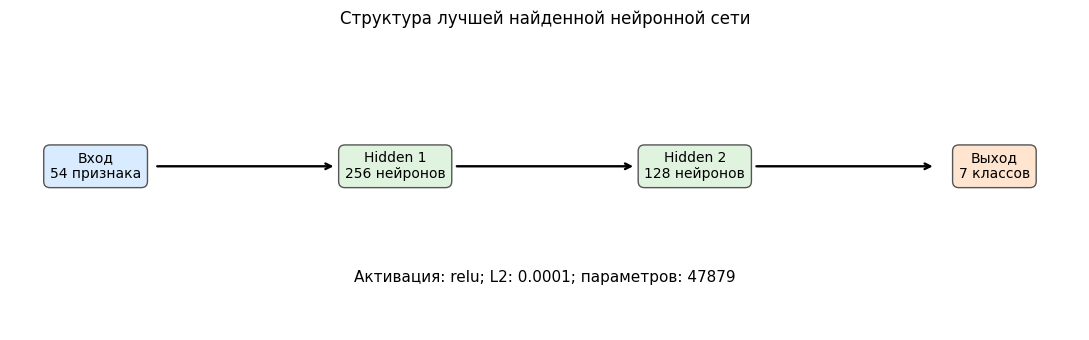

In [37]:
def plot_architecture(individual: Individual) -> None:
    layer_sizes = [N_FEATURES] + individual.hidden_layers + [N_CLASSES]
    layer_names = [f"Вход\n{N_FEATURES} признака"] + [f"Hidden {i + 1}\n{size} нейронов" for i, size in enumerate(individual.hidden_layers)] + [f"Выход\n{N_CLASSES} классов"]

    fig, ax = plt.subplots(figsize=(11, 3.5))
    x_positions = np.linspace(0.08, 0.92, len(layer_sizes))
    for index, (x_pos, name) in enumerate(zip(x_positions, layer_names)):
        color = "#d9ecff" if index == 0 else "#dff3df" if index < len(layer_sizes) - 1 else "#ffe5d0"
        ax.text(
            x_pos,
            0.55,
            name,
            ha="center",
            va="center",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.45", facecolor=color, edgecolor="#555555"),
        )
        if index < len(layer_sizes) - 1:
            ax.annotate("", xy=(x_positions[index + 1] - 0.055, 0.55), xytext=(x_pos + 0.055, 0.55), arrowprops=dict(arrowstyle="->", lw=1.7))

    ax.text(0.5, 0.16, f"Активация: {individual.activation}; L2: {individual.l2}; параметров: {evolved_metrics['params']}", ha="center", fontsize=11)
    ax.set_title("Структура лучшей найденной нейронной сети")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / "best_architecture.png", dpi=160)
    plt.show()


plot_architecture(best_individual)


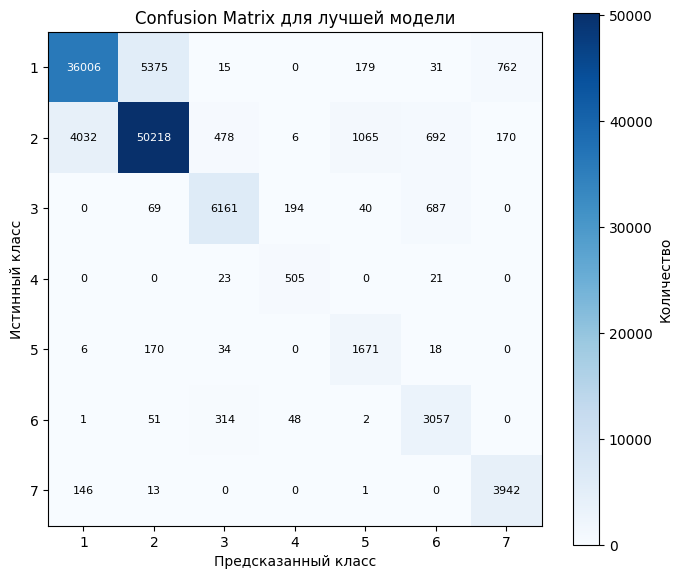

In [38]:
cm = confusion_matrix(y_test, evolved_metrics["test_predictions"])

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix для лучшей модели")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.colorbar(label="Количество")
for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        plt.text(col, row, str(cm[row, col]), ha="center", va="center", fontsize=8, color="white" if cm[row, col] > cm.max() / 2 else "black")
plt.xticks(range(N_CLASSES), range(1, N_CLASSES + 1))
plt.yticks(range(N_CLASSES), range(1, N_CLASSES + 1))
plt.tight_layout()
plt.savefig(output_dir / "confusion_matrix.png", dpi=160)
plt.show()


In [39]:
report_text = classification_report(
    y_test,
    evolved_metrics["test_predictions"],
    target_names=[f"Класс {index}" for index in range(1, N_CLASSES + 1)],
)
(output_dir / "classification_report.txt").write_text(report_text, encoding="utf-8")
print(report_text)


              precision    recall  f1-score   support

     Класс 1       0.90      0.85      0.87     42368
     Класс 2       0.90      0.89      0.89     56661
     Класс 3       0.88      0.86      0.87      7151
     Класс 4       0.67      0.92      0.78       549
     Класс 5       0.56      0.88      0.69      1899
     Класс 6       0.68      0.88      0.77      3473
     Класс 7       0.81      0.96      0.88      4102

    accuracy                           0.87    116203
   macro avg       0.77      0.89      0.82    116203
weighted avg       0.88      0.87      0.88    116203



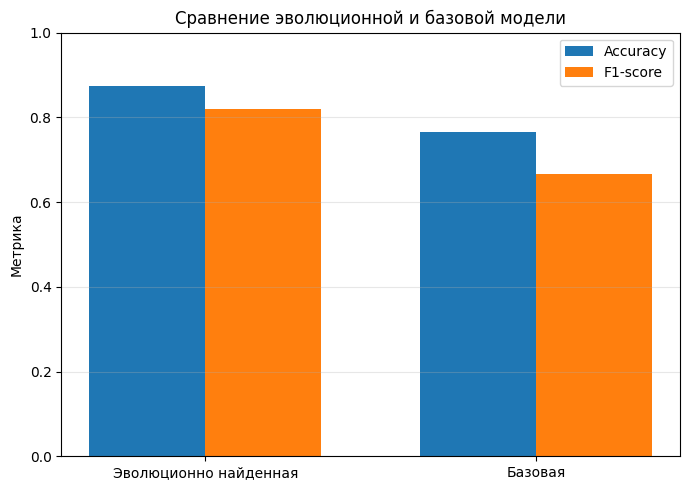

In [40]:
plt.figure(figsize=(7, 5))
x = np.arange(len(comparison))
width = 0.35
plt.bar(x - width / 2, comparison["Accuracy test"], width, label="Accuracy")
plt.bar(x + width / 2, comparison["F1 test"], width, label="F1-score")
plt.xticks(x, comparison["Модель"])
plt.ylim(0, 1.0)
plt.ylabel("Метрика")
plt.title("Сравнение эволюционной и базовой модели")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "baseline_comparison.png", dpi=160)
plt.show()


## Сохранение результатов

Сохраняются графики, история эволюции и таблица сравнения моделей.


In [41]:
history_df.to_csv(output_dir / "evolution_history.csv", index=False, encoding="utf-8-sig")
comparison.to_csv(output_dir / "comparison.csv", index=False, encoding="utf-8-sig")

print("История эволюции сохранена:", output_dir / "evolution_history.csv")
print("Сравнение моделей сохранено:", output_dir / "comparison.csv")


История эволюции сохранена: c:\Users\motyn\Desktop\repositories\_OMSTU\EVAL\lab_4\results\evolution_history.csv
Сравнение моделей сохранено: c:\Users\motyn\Desktop\repositories\_OMSTU\EVAL\lab_4\results\comparison.csv


## Анализ результатов

Эволюционный алгоритм подбирает не веса сети, а ее архитектуру: число скрытых слоев, количество нейронов, активацию и регуляризацию. Такой подход позволяет искать более удачную конфигурацию, не перебирая параметры вручную.

Фитнес-функция максимизирует точность на валидационной выборке, но добавляет штраф за сложность модели. Поэтому большая сеть должна не просто иметь больше параметров, а реально давать выигрыш по качеству. Число скрытых слоев не зафиксировано вручную: алгоритм может выбирать от `1` до `5` слоев, а лишние слои ограничиваются штрафом.

Если лучшая архитектура повторяется несколько поколений, это означает плато: элитизм сохраняет лучшую особь, а новые варианты пока не дают лучшего fitness. Для уменьшения такого застоя добавлены уникальность архитектур в поколении, случайные иммигранты и усиленное обновление популяции при стагнации.

Датасет Covertype подходит под требование задания: это реальный большой набор для классификации, содержащий 54 признака. Из-за высокой стоимости оценки каждой архитектуры эволюционный поиск выполняется на стратифицированной подвыборке, а финальная модель обучается и проверяется уже на больших train/test частях датасета.


## Вывод

В работе реализована эволюционная программа для оптимизации архитектуры полносвязной нейронной сети. Программа использует реальный датасет Forest Covertype, выполняет чанковую обработку данных, строит временные модели для особей популяции, оценивает фитнес по Accuracy со штрафом за сложность и сравнивает найденную архитектуру с базовой моделью.
